In [11]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter


sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *

system = platform.system()

if system == 'Linux':
    home = '/home/gerard/data/confocal/'
elif system == 'Darwin':
    home = '/Users/gerard/data/confocal/'
elif system == "Windows":
    home = 'C:/Users/cviko/data/confocal/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
date = '2026_06_05'
user = 'Carmina'

info = describe_acquisition( home + date + '_' + user + '/Project.lif')

....

══════════════════════════════════════════════════════════════
Scene 0: dec02_5x_brain1alphaprime_L
══════════════════════════════════════════════════════════════
  Objective  : HC PL APO CS2    63x/1.40 OIL
  NA / n     : 1.4 / 1.518
  Voxel size : XY = 0.0226 µm/px  |  Z = 0.1307 µm/step
  Shape      : 61 × 512 × 512  (Z × Y × X)

  ────────────────────────────────────── Acquisition sequences
  Seq 1  laser(s): 488 nm + 638 nm  [simultaneous]
         pinhole  : 20.00 µm  (0.209 AU)
         det ch1  501–610 nm  Leica/ALEXA 488         em = 519 nm
         det ch2  643–788 nm  Leica/Cy5               em = 670 nm
  Seq 2  laser(s): 552 nm
         pinhole  : 20.00 µm  (0.209 AU)
         det ch2  557–761 nm  Leica/ALEXA 546         em = 573 nm

  ────────────────────────────────────── Image channels (0-indexed)
  ch0  Leica/ALEXA 488         em=519 nm  σ_xy=3.45px (0.078µm) [✓]  σ_z=2.03px [✓]  → 3D
  ch1  Leica/Cy5               em=670 nm  σ_xy=4.45px (0.101µm) [✓]  σ_z=2.62px 

In [4]:
loader2(date,user,False, False)

C:/Users/cviko/data/confocal/2026_06_05_Carmina
Number of series: 10
series 0: shape = (1, 3, 61, 512, 512)
series 1: shape = (1, 3, 134, 512, 512)
series 2: shape = (1, 3, 121, 512, 512)
series 3: shape = (1, 3, 88, 512, 512)
series 4: shape = (1, 3, 174, 512, 512)
series 5: shape = (1, 3, 121, 512, 512)
series 6: shape = (1, 3, 127, 512, 512)
series 7: shape = (1, 3, 197, 512, 512)
series 8: shape = (1, 3, 101, 512, 512)
series 9: shape = (1, 3, 94, 512, 512)


### DECONVOLUTION :
https://en.wikipedia.org/wiki/Richardson%E2%80%93Lucy_deconvolution

In [6]:


path_data = date + '_' + user + '/Project.lif'
path_data_all = home + path_data #os.path.join(hom

print(path_data_all)
img = AICSImage(path_data_all)
# print(len(img.scenes))
# print(img.scenes[0])



C:/Users/cviko/data/confocal/2026_06_05_Carmina/Project.lif


In [10]:
#list_numbers = [1,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
words = ['hola', 'adios', 'buenos dias', 'buenas tardes', 'buenas noches']
people = ['Alice', 'Bob', 'Charlie', 'David', 'Eve']
for name in people:
    for word in words:
        print(f'{name}, {word}')
    

Alice, hola
Alice, adios
Alice, buenos dias
Alice, buenas tardes
Alice, buenas noches
Bob, hola
Bob, adios
Bob, buenos dias
Bob, buenas tardes
Bob, buenas noches
Charlie, hola
Charlie, adios
Charlie, buenos dias
Charlie, buenas tardes
Charlie, buenas noches
David, hola
David, adios
David, buenos dias
David, buenas tardes
David, buenas noches
Eve, hola
Eve, adios
Eve, buenos dias
Eve, buenas tardes
Eve, buenas noches


In [11]:


series_list = list(range(len(info.keys())))

## DESIRED NUMBER OF ITERATIONS:
iterations = [
            # 1,        
            # 2,
            3,
            4,
            5,
            # 6,
            # 7, 
            #10, 
            # 15,
            20,#result[bg].std() / original[bg].std()
            ]

for series in series_list:
    img.set_scene(img.scenes[series])
    channels = list(range(len(info[list(info.keys())[series]]['image_channels'])))
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            print(f'iteration {num_iter} for series {series} channel {channel}')
            background_noise_ratios = []
            
            # actual deconvolution:
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=series, num_iter=num_iter)
            

iteration 3 for series 0 channel 0
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (2.03 px) → 3D
2026_06_05_s0_ch0_deconv_iter_3.tif
iteration 4 for series 0 channel 0
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (2.03 px) → 3D
2026_06_05_s0_ch0_deconv_iter_4.tif
iteration 5 for series 0 channel 0
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (2.03 px) → 3D
2026_06_05_s0_ch0_deconv_iter_5.tif
iteration 20 for series 0 channel 0
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (2.03 px) → 3D
2026_06_05_s0_ch0_deconv_iter_20.tif
iteration 3 for series 0 channel 1
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (4.45 px) | σ_z=0.342 µm (2.62 px) → 3D
2026_06_05_s0_ch1_deconv_iter_3.tif
iteration 4 for series 0 channel 1
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (4.45 px) | σ_z=0.342 µm (2.62 px) → 3D
2026_06_05_s0_ch1_deconv_iter_4.tif
iteration 5 for series 0 channel 1
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (4.45 px) | σ_z=0.342 µm (2.62 px) → 3D
2026_

KeyboardInterrupt: 

### TRESHOLDING


C:/Users/cviko/data/confocal/2026_06_05_Carmina/Project.lif
....
Processing series 5---------------
Channel 0************************
raw ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0.tif
treshold using triangle = 10
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_masks_triangle.tif
treshold using otsu = 26
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_masks_otsu.tif
treshold using yen = 173
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_masks_yen.tif
treshold using li = 17.352683921069275
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_masks_li.tif


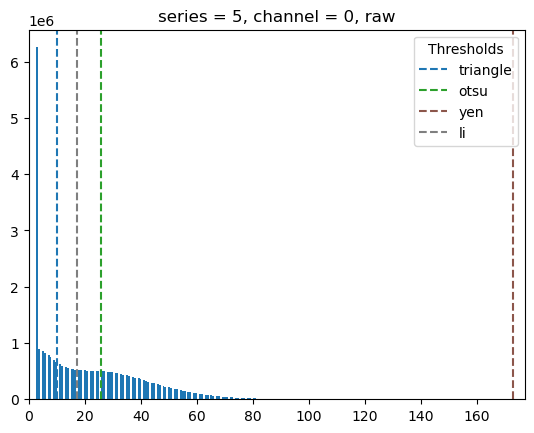

deconv_iter_2 ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_deconv2d_iter_2.tif
treshold using triangle = 14.206274032592773
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_deconv2d_iter_2_masks_triangle.tif
treshold using otsu = 21.57013702392578
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_deconv2d_iter_2_masks_otsu.tif


c:\Users\cviko\miniconda3\envs\leica-env\Lib\site-packages\skimage\filters\thresholding.py:440: RuntimeWarning: divide by zero encountered in log
  crit = np.log(((P1_sq[:-1] * P2_sq[1:]) ** -1) *


treshold using yen = 80.91419982910156
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_deconv2d_iter_2_masks_yen.tif
treshold using li = 17.172017605266763
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_0\2026_06_05_s5_ch0_deconv2d_iter_2_masks_li.tif


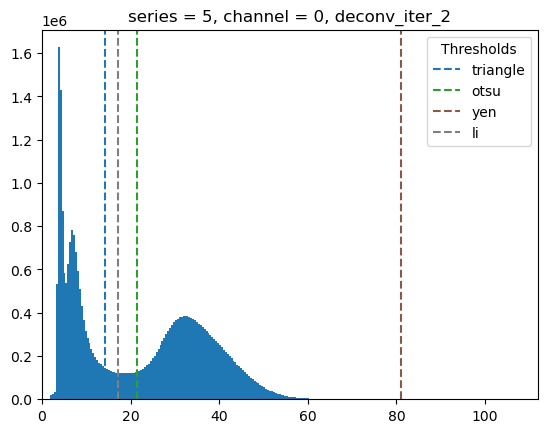

Channel 1************************
raw ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1.tif
treshold using triangle = 5
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_masks_triangle.tif
treshold using otsu = 21
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_masks_otsu.tif
treshold using yen = 149
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_masks_yen.tif
treshold using li = 10.799581231542717
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_masks_li.tif


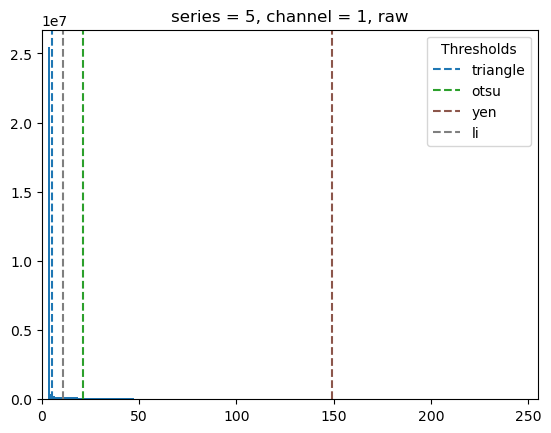

deconv_iter_2 ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_deconv2d_iter_2.tif
treshold using triangle = 11.266563415527344
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_deconv2d_iter_2_masks_triangle.tif
treshold using otsu = 6.650639057159424
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_deconv2d_iter_2_masks_otsu.tif
treshold using yen = 6.24925422668457
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_deconv2d_iter_2_masks_yen.tif
treshold using li = 6.246221188213387
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_1\2026_06_05_s5_ch1_deconv2d_iter_2_masks_li.tif


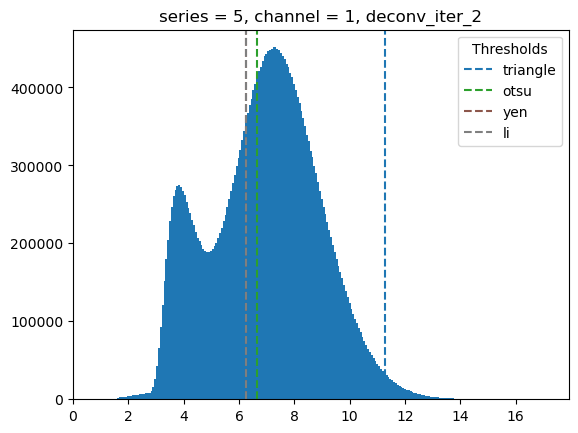

Channel 2************************
raw ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2.tif
treshold using triangle = 5
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_masks_triangle.tif
treshold using otsu = 25
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_masks_otsu.tif
treshold using yen = 60
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_masks_yen.tif
treshold using li = 12.295291078239048
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_masks_li.tif


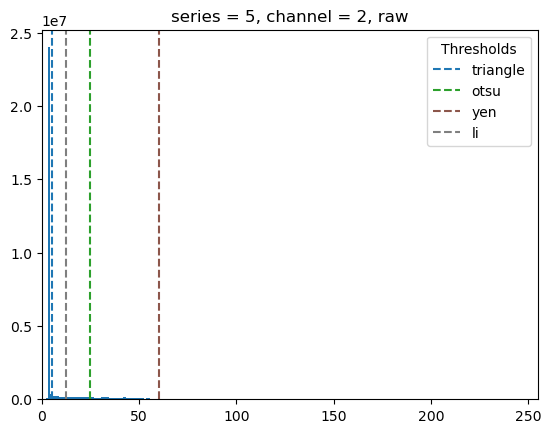

deconv_iter_2 ************************
C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_deconv2d_iter_2.tif
treshold using triangle = 8.536361694335938
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_deconv2d_iter_2_masks_triangle.tif
treshold using otsu = 11.823208808898926
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_deconv2d_iter_2_masks_otsu.tif
treshold using yen = 12.234064102172852
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_deconv2d_iter_2_masks_yen.tif
treshold using li = 9.538939300966918
saved C:/Users/cviko/data/confocal/2026_06_05_Carmina\series_5\channel_2\2026_06_05_s5_ch2_deconv2d_iter_2_masks_li.tif


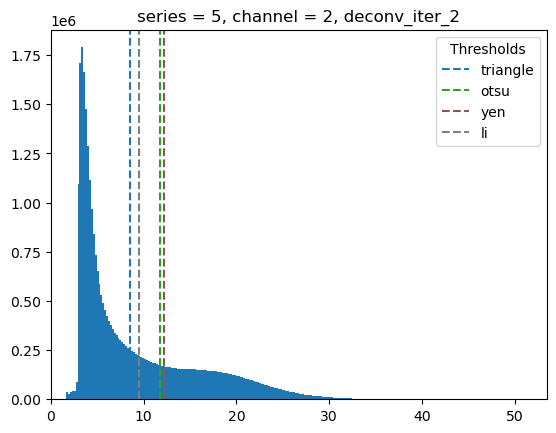

In [10]:
#thresholding(date, user, series_list, deconv_iter_list, do_plot = True )
results = thresholding(date, user, [5], [2], do_plot = True )